# Waste generation prediction — deep learning

Same features, target, and train/test split as `00_basemodel.ipynb`, so the comparison to XGBoost (R2=0.81 single split, CV mean 0.78 +/- 0.07) is fair. This dataset is cross-sectional (one row per city, no time axis), so the DL model here is a feedforward MLP, not an LSTM — there's no sequence to feed a recurrent layer.

With only 326 rows, the literature expectation is that tree ensembles tend to beat neural nets in this small-data regime. Worth testing rather than assuming.

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)

df = pd.read_csv("../data/WhatAWaste_City_Level.csv")
target = "total_msw_total_msw_generated_tons_year"
df[target] = pd.to_numeric(df[target].astype(str).str.replace(",", "", regex=False), errors="coerce")

features = [
    "population_population_number_of_people",
    "income_id",
    "region_id",
    "composition_food_organic_waste_percent",
    "composition_paper_cardboard_percent",
    "composition_plastic_percent",
    "composition_glass_percent",
    "composition_metal_percent",
    "composition_other_percent",
]

data = df[features + [target]].dropna(subset=[target]).copy()
data.shape

I0000 00:00:1782398150.319446  220207 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


(326, 10)

## Feature prep

Same as the ML baseline (log-transform population/target, median-impute composition, one-hot income/region) plus one extra step neural nets need that trees don't: scaling all inputs to a comparable range with `StandardScaler`.

In [2]:
data["log_population"] = np.log1p(data["population_population_number_of_people"])
data["log_target"] = np.log1p(data[target])

composition_cols = [c for c in features if c.startswith("composition_")]
imputer = SimpleImputer(strategy="median")
data[composition_cols] = imputer.fit_transform(data[composition_cols])

data = pd.get_dummies(data, columns=["income_id", "region_id"], drop_first=True)

feature_cols = [c for c in data.columns if c not in (target, "log_target", "population_population_number_of_people")]
X = data[feature_cols]
y = data["log_target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.shape, X_test_scaled.shape

((260, 16), (66, 16))

## Model

Small MLP — 326 rows can't support a deep/wide network without overfitting immediately. Two small hidden layers, dropout, and early stopping on a validation split.

In [3]:
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(16, activation="relu"),
    layers.Dense(1),
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01), loss="mse")

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0,
)

print("stopped at epoch:", len(history.history["loss"]))

W0000 00:00:1782398152.234955  220262 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1782398152.285221  220207 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


stopped at epoch: 87


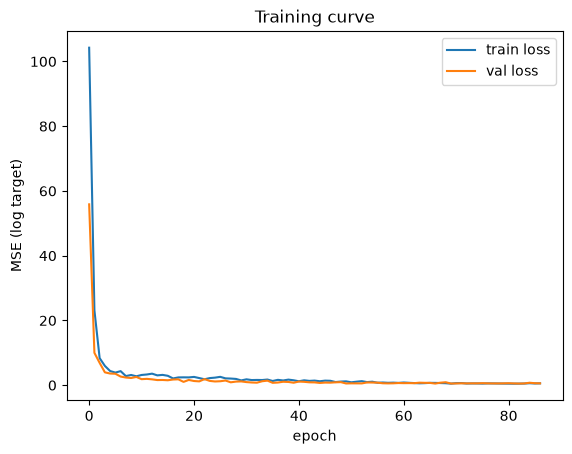

In [4]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("MSE (log target)")
plt.legend()
plt.title("Training curve")
plt.show()

In [5]:
pred_log = model.predict(X_test_scaled, verbose=0).flatten()
pred = np.expm1(pred_log)
actual = np.expm1(y_test)

mae = mean_absolute_error(actual, pred)
rmse = np.sqrt(mean_squared_error(actual, pred))
r2 = r2_score(actual, pred)

print(f"MLP: MAE={mae:,.0f} tons, RMSE={rmse:,.0f} tons, R2={r2:.3f}")

MLP: MAE=317,812 tons, RMSE=799,060 tons, R2=0.434


## Comparison to the ML baseline

| Model | R2 (single split, seed=42) | CV R2 (mean +/- std) |
|---|---|---|
| XGBoost | 0.811 | 0.780 +/- 0.070 |
| Random Forest | 0.804 | 0.708 +/- 0.090 |
| MLP | 0.434 | *(not run — 326 rows is too little to also hold out a CV loop here without further shrinking the training set)* |

## Conclusion

The MLP (R2=0.434) is clearly worse than both tree ensembles, confirming the expectation from the intro: with only 326 rows, a neural net doesn't have enough examples to learn useful nonlinear feature interactions, and instead overfits/underfits relative to a method (gradient-boosted/random forest trees) that's far more sample-efficient on small tabular data.

This isn't a tuning failure to chase — it's a real, well-documented pattern: deep learning's advantage shows up with thousands-to-millions of rows (like the traffic and air quality datasets), not hundreds. For this domain, **XGBoost remains the better model**, and that conclusion itself is a legitimate finding for the project writeup: it shows we understand *when* DL helps and when it doesn't, rather than defaulting to "deep learning is better" without checking.